## Batch Parameters and Aggregation
This section lets you set parameters, call the R script for one or more CSVs, and aggregate results into a long-format summary where each row is a channel with `uL_mg_hr`, `temp_C`, and placeholder metadata.

## Configuration

Set paths and default parameters.

In [31]:
import pandas as pd
import subprocess
from pathlib import Path

# Paths
DATA_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025')
OUT_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed')
R_SCRIPT = Path('/Users/oakley/Documents/GitHub/signal_respirometry/scripts/consumption_rate.R')

# Create output directory if needed
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Default parameters
DEFAULT_SAL = 33
DEFAULT_CONTROL = 'Ch1'
DEFAULT_CHANNELS = ['Ch2', 'Ch3', 'Ch4']
DEFAULT_MASSES = [0.00024, 0.00024, 0.00024]  # grams
DEFAULT_VOL_CONTROL = 0.002  # liters
DEFAULT_VOLUMES = [0.002, 0.002, 0.002]  # liters
DEFAULT_START_HOUR = 1
DEFAULT_END_HOUR = 8
DEFAULT_MICROBIAL_CUTOFF = 5

## Define Trial Runs

Each run is a dictionary with trial-specific parameters and meta-data.

In [49]:
# Define your runs here
# Each run can override defaults or use them

# Trial 1 (10 Nov 2025) - night environment
# Box2: small vessels (2ml), 1 animal each
# Box3: cylinders (260-268ml), 20 animals each
# Newbox: small vessels (2ml), 1 animal each - using newpyro CSV format

runs = [
    {
        'trial': 'trial1',
        'brick': 'box2',
        'csv': DATA_DIR / 'Ostracods-trial1-box2-10Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial1',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial1-box3-10Nov.csv',
        'masses': [0.0048, 0.0048, 0.0048],  # 20 animals × 0.00024 = 0.0048 g
        'volumes': [0.264, 0.262, 0.260],  # cylinders in ml → L
        'vol_control': 0.268,  # Ch1 control cylinder
        'metadata': {
            'vessel': 'cylinder',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial1',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial1.csv',  # Using newpyro CSV format
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },
    # Trial 2 (11 Nov 2025) - night environment
    # NOTE: Box2 and Box3 had crashes during this trial
    # Only Newbox: medium vessels (25ml), 5 animals each
    {
        'trial': 'trial2',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial2.csv',  # Using newpyro CSV format
        'masses': [0.0012, 0.0012, 0.0012],  # 5 animals × 0.00024 = 0.0012 g
        'volumes': [0.025, 0.025, 0.025],  # 25 ml each
        'vol_control': 0.025,
        'metadata': {
            'vessel': 'medium',
            'date': '11Nov2025',
            'environment': 'night'
        }
    },
    # Trial 3 (12 Nov 2025) - night environment
    # Box2: cylinders (260, 262, 264, 268 ml), 20 animals each
    # Box3: medium vessels (25ml), 5 animals each
    # Newbox: small vessels (2ml), 1 animal each
    {
        'trial': 'trial3',
        'brick': 'box2',
        'csv': DATA_DIR / 'Ostracods-trial3-box2-12Nov.csv',
        'masses': [0.0048, 0.0048, 0.0048],  # 20 animals × 0.00024 = 0.0048 g
        'volumes': [0.260, 0.262, 0.264],  # cylinders Ch2, Ch3, Ch4 in L
        'vol_control': 0.268,  # Ch1 control cylinder
        'metadata': {
            'vessel': 'cylinder',
            'date': '12Nov2025',
            'environment': 'night',
            'notes': 'Ch2 closest to GoPro, Ch4 farthest from GoPro'
        }
    },
    {
        'trial': 'trial3',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial3-box3-12Nov.csv',
        'masses': [0.0012, 0.0012, 0.0012],  # 5 animals × 0.00024 = 0.0012 g
        'volumes': [0.025, 0.025, 0.025],  # 25 ml each
        'vol_control': 0.025,
        'metadata': {
            'vessel': 'medium',
            'date': '12Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial3',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial3.csv',  # Using newpyro CSV format
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '12Nov2025',
            'environment': 'night'
        }
    },
    # Trial 4 (13 Nov 2025) - night environment
    # Box2: small vessels (2ml), 1 animal each
    # Box3: small vessels (2ml), 1 animal each
    # Newbox: cylinders (260, 262, 264, 268 ml), 20 animals each
    {
        'trial': 'trial4',
        'brick': 'box2',
        'csv': DATA_DIR / 'Ostracods-trial4-box2-13Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial4',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial4-box3-13Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },

#Default parameters give negative rates. The early microbial rate (control) looks really high
#Perhaps that is an artifact of non-mixing or somthing?
#Try to set start hour to 3
    {
        'trial': 'trial4',
        'brick': 'newbox',
        'start_hour': 3,
        'csv': DATA_DIR / 'Ostracods-trial4-newbox-13Nov.csv',
        'masses': [0.0048, 0.0048, 0.0048],  # 20 animals per cylinder
        'volumes': [0.260, 0.262, 0.264],  # cylinders Ch2, Ch3, Ch4
        'vol_control': 0.268,  # Ch1 control cylinder
        'metadata': {
            'vessel': 'cylinder',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },
    # Trial 4.5 (14 Nov 2025) - day environment (same animals as Trial 4)
    {
        'trial': 'trial4.5',
        'brick': 'box2',
        'csv': DATA_DIR / 'Ostracods-trial4-light-box2-14Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial4'
        }
    },
    {
        'trial': 'trial4.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial4-light-box3-14Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial4'
        }
    },
    # Trial 4.5 newbox not available (no CSV provided)

    # Trial 5 (14 Nov 2025) - night environment
    {
        'trial': 'trial5',
        'brick': 'box2',
        'csv': DATA_DIR / 'Ostracods-trial5-box2-14Nov.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Only 3 channels
        'masses': [0.0048, 0.0048],  # 20 animals per cylinder
        'volumes': [0.260, 0.262],  # Ch2=260ml, Ch3=262ml, Ch4=268ml
        'vol_control': 0.268,  # Using Ch4 (268ml) as pseudo-control
        'ignore': 'Ch4',
        'metadata': {
            'vessel': 'cylinder',
            'date': '14Nov2025',
            'environment': 'night',
            'notes': 'One cylinder broke, only 3 channels available'
        }
    },
    {
        'trial': 'trial5',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial5-box3-14Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'Ostracods-trial5-newbox-14Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'night'
        }
    },
    ## Trial 5.5 (15 Nov 2025) - day environment (same animals as Trial 5)
    ## Cannot locate original data
    #{
    #    'trial': 'trial5.5',
    #    'brick': 'box2',
    #    'csv': DATA_DIR / 'Ostracods-trial5-box2-14Nov.csv',  # Reusing night CSV as placeholder
    #    'channels': ['Ch2', 'Ch3', 'Ch4'],
    #    'masses': [0.0048, 0.0048, 0.0048],
    #    'volumes': [0.260, 0.262, 0.268],
    #    'vol_control': 0.268,
    #    'metadata': {
    #        'vessel': 'cylinder',
    #        'date': '15Nov2025',
    #        'environment': 'day',
    #        'notes': 'Same animals as trial5, one cylinder broke'
    #    }
    #},
    {
        'trial': 'trial5.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'Ostracods-trial5-light-newbox-.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '15Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial5'
        }
    },
    # Trial 6 (16 Nov 2025) - day environment
{
        'trial': 'trial6',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial6-light-box3-16Nov.csv',
        'control': 'Ch1',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'day',
            'notes': 'Ch1 serves as control for both box3 and newbox'
        }
    },

    {
        'trial': 'trial6',
        'brick': 'newbox',
        'csv': DATA_DIR / 'Ostracods-trial6-light-newbox-.csv',
        'control': 'Ch1',
        'control-csv': DATA_DIR / 'Ostracods-trial6-light-box3-16Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'day',
            'notes': 'Ch1 serves as control for both box3 and newbox'
        }
    },
    # Trial 6.5 (16 Nov 2025) - night environment (same animals as Trial 6)
    {
        'trial': 'trial6.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial6-dark-box3-16Nov.csv',
        'control': 'Ch1',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'night',
            'notes': 'Ch1 serves as control for both box3 and newbox'
        }
    },
    {
        'trial': 'trial6.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'Ostracods-trial6-dark-newbox-1.csv',
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'Ostracods-trial6-dark-box3-16Nov.csv',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial6; Ch1 serves as control for both box3 and newbox'
        }
    },
    # Trial 7 (17 Nov 2025) - day environment
    {
        'trial': 'trial7',
        'brick': 'newbox',
        'csv': DATA_DIR / 'Ostracods-trial7-light-newbox-.csv',
        'control': 'Ch1',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'control_csv': DATA_DIR / 'Ostracods-trial7-light-box3-17Nov.csv',
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'day',
            'notes': 'Ch1 serves as control for both box3 and newbox'
        }
    },
        {
        'trial': 'trial7',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial7-light-box3-17Nov.csv',
        'control': 'Ch1',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'day',
            'notes': 'Ch1 serves as control for both box3 and newbox'
        }
    },
    # Trial 7.5 (17 Nov 2025) - night environment (same animals as Trial 7)
    {
        'trial': 'trial7.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'Ostracods-trial7-dark-newbox-1.csv',
        'control': 'Ch1',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'control_csv': DATA_DIR / 'Ostracods-trial7-dark-box3-17Nov.csv',
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial7; Ch1 serves as control for both box3 and newbox'
        }
    },
    {
        'trial': 'trial7.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'Ostracods-trial7-dark-box3-17Nov.csv',
        'control': 'Ch1',
        'masses': [0.00024, 0.00024, 0.00024],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial7; Ch1 serves as control for both box3 and newbox'
        }
    },
]




#****************** Define Helper functions to call the R Script ******************#

def run_respirometry_analysis(run, defaults=None):
    """
    Call consumption_rate.R for a single run.
    
    Args:
        run: dict with 'csv', 'trial', 'brick', and optional parameters
        defaults: dict with default values for missing parameters
    
    Returns:
        tuple: (success: bool, message: str)
    """
    if defaults is None:
        defaults = {}
    
    csv_path = run['csv']
    if not csv_path.exists():
        return False, f"CSV not found: {csv_path}"
    
    # Build R script arguments
    args = [
        'Rscript', '--vanilla', str(R_SCRIPT),
        '--csv', str(csv_path),
        '--sal', str(run.get('sal', defaults.get('sal', DEFAULT_SAL))),
        '--control', run.get('control', defaults.get('control', DEFAULT_CONTROL)),
        '--channels', ','.join(run.get('channels', defaults.get('channels', DEFAULT_CHANNELS))),
        '--masses', ','.join(str(m) for m in run.get('masses', defaults.get('masses', DEFAULT_MASSES))),
        '--vol_control', str(run.get('vol_control', defaults.get('vol_control', DEFAULT_VOL_CONTROL))),
        '--volumes', ','.join(str(v) for v in run.get('volumes', defaults.get('volumes', DEFAULT_VOLUMES))),
        '--start_hour', str(run.get('start_hour', defaults.get('start_hour', DEFAULT_START_HOUR))),
        '--end_hour', str(run.get('end_hour', defaults.get('end_hour', DEFAULT_END_HOUR))),
        '--microbial_cutoff_hour', str(run.get('microbial_cutoff_hour', defaults.get('microbial_cutoff_hour', DEFAULT_MICROBIAL_CUTOFF))),
        '--out', str(OUT_DIR),
    ]
    
    # Add optional flags if specified
    if run.get('mask_channels', False):
        args += ['--mask_channels', 'true']
    if 'cutoff_inclusive' in run:
        args += ['--cutoff_inclusive', 'true' if run['cutoff_inclusive'] else 'false']
    if run.get('debug', False):
        args += ['--debug', 'true']
    if 'ignore' in run:
        args += ['--ignore', run['ignore']]
    
    # Run R script
    try:
        result = subprocess.run(
            args,
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        return True, f"Success: {run['trial']}-{run['brick']}"
    except subprocess.CalledProcessError as e:
        error_msg = f"Failed: {run['trial']}-{run['brick']}\n"
        if e.stderr:
            error_msg += f"Error: {e.stderr}"
        return False, error_msg

## Plot Data

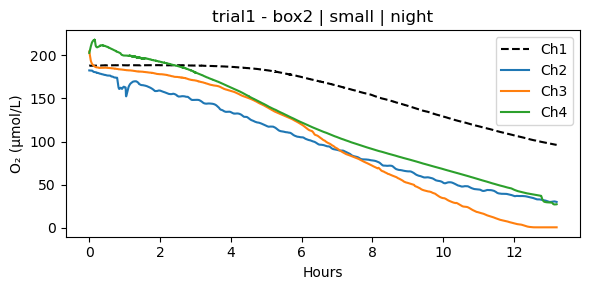

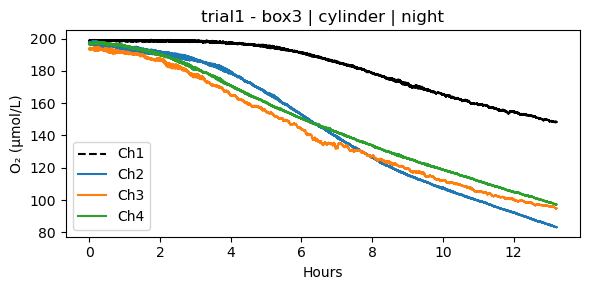

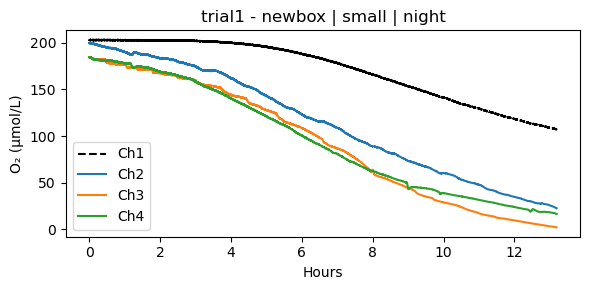

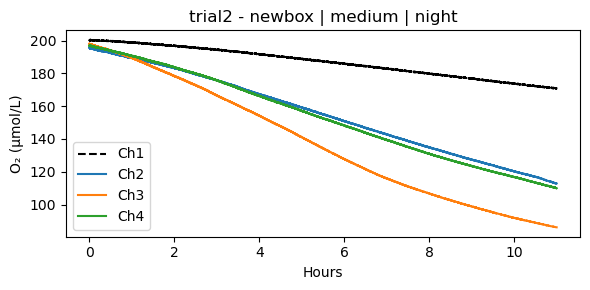

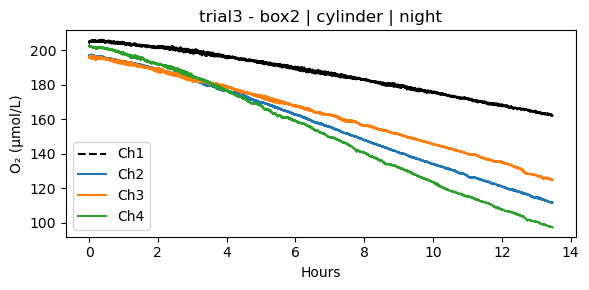

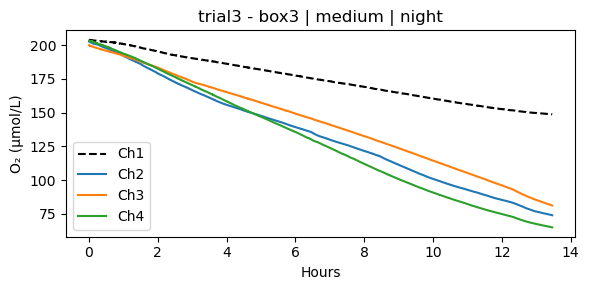

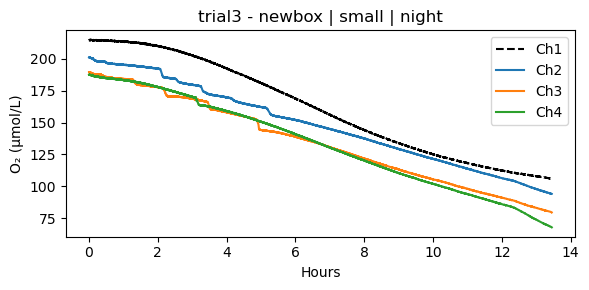

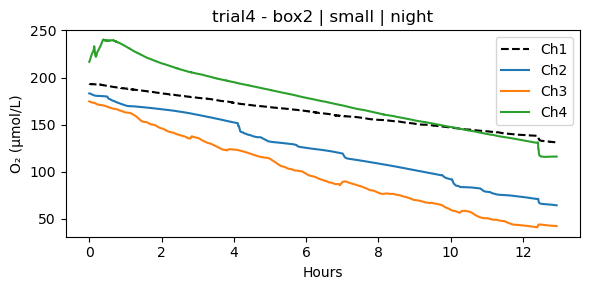

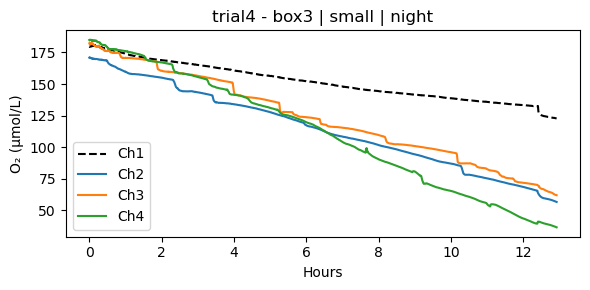

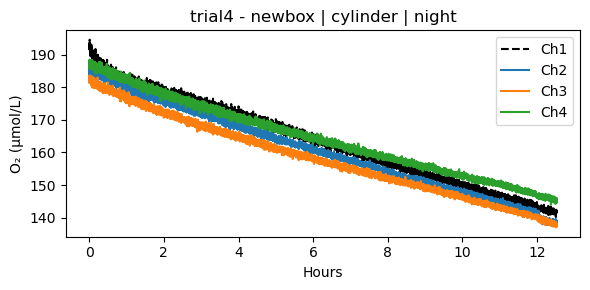

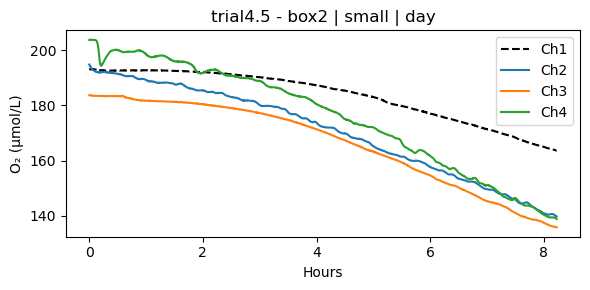

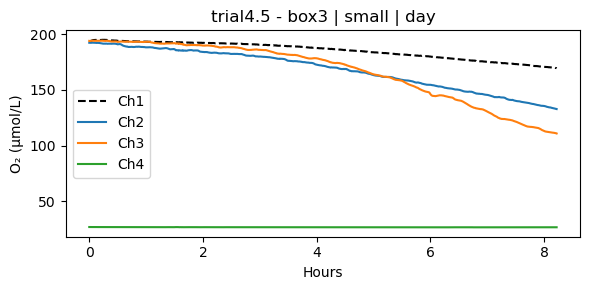

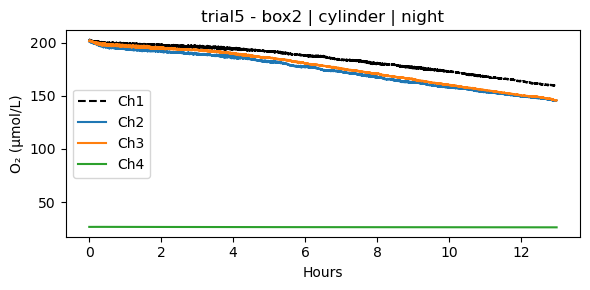

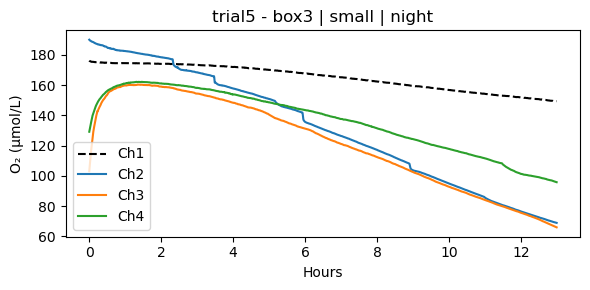

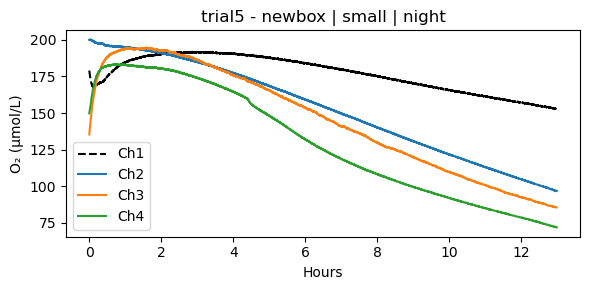

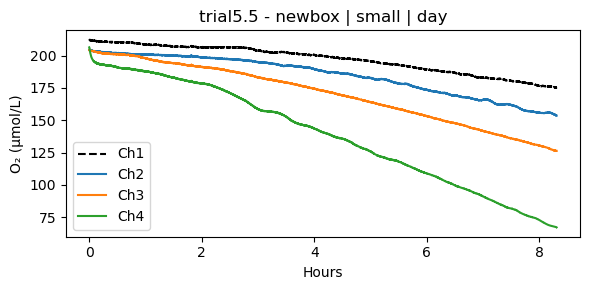

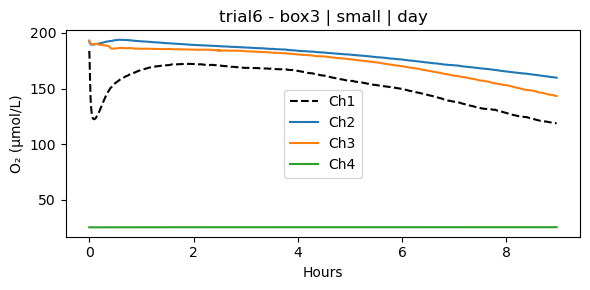

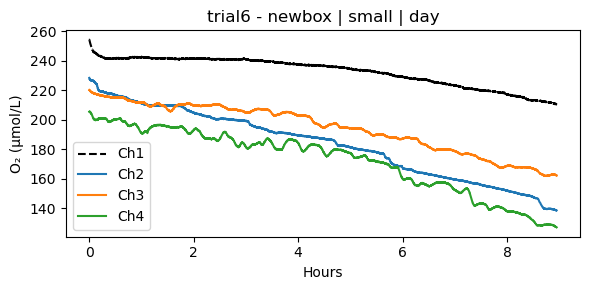

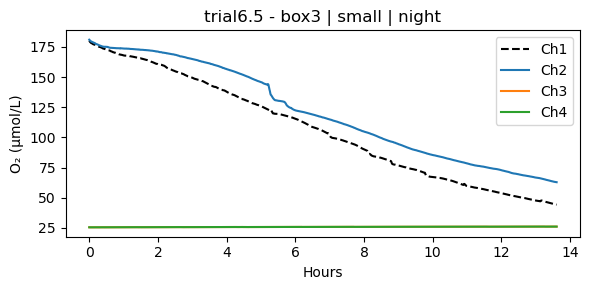

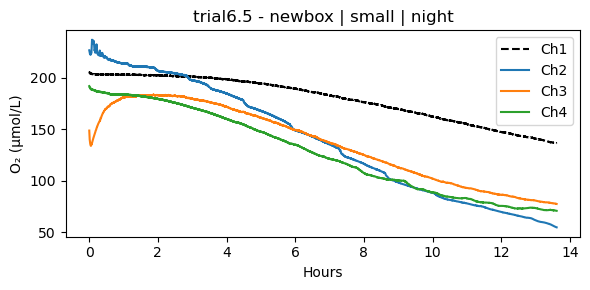

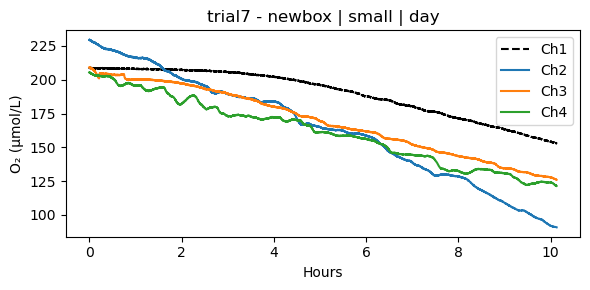

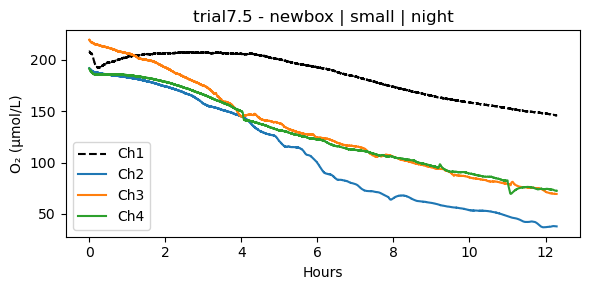

In [5]:
# Batch Data QC Plots (Collapsible)
import matplotlib.pyplot as plt
from IPython.display import display, HTML

for run in runs:
    csv_path = run['csv']
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f'Could not read {csv_path}: {e}')
        continue
    fig, ax = plt.subplots(figsize=(6, 3))
    # Always plot Ch1 if present
    if 'Ch1' in df.columns:
        ax.plot(df['hours'], df['Ch1'], label='Ch1', linestyle='--', color='black')
    # Plot all other channels in run config
    for ch in run.get('channels', DEFAULT_CHANNELS):
        if ch in df.columns:
            ax.plot(df['hours'], df[ch], label=ch)
    # Optionally highlight the control channel if specified and not Ch1
    if 'control' in run and run['control'] in df.columns and run['control'] != 'Ch1':
        ax.plot(df['hours'], df[run['control']], label=f"{run['control']} (control)", linestyle=':', color='red')
    vessel = run.get('metadata', {}).get('vessel', '')
    environment = run.get('metadata', {}).get('environment', '')
    ax.set_title(f"{run['trial']} - {run['brick']} | {vessel} | {environment}")
    ax.set_xlabel('Hours')
    ax.set_ylabel('O₂ (µmol/L)')
    ax.legend()
    plt.tight_layout()
    # Wrap each plot in a collapsible HTML details tag
    display(HTML(f'<details><summary>{run["trial"]} - {run["brick"]}</summary>'))
    display(fig)
    display(HTML('</details>'))
    plt.close(fig)


In [6]:
# --- Run and view a single run (ad hoc) ---
# Example: rerun and inspect just trial 4 newbox
single_run = next(r for r in runs if r['trial'] == 'trial4' and r['brick'] == 'newbox')
success, message = run_respirometry_analysis(single_run)
print(message)

# Load and display the summary for this run, one row per channel, with extra parameters
csv_name = single_run['csv'].name
summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"
if summary_path.exists():
    r_df = pd.read_csv(summary_path)
    # Reshape: gather all *_uL_mg_hr columns into rows
    channel_cols = [col for col in r_df.columns if col.endswith('_uL_mg_hr')]
    rows = []
    for col in channel_cols:
        channel = col.replace('_uL_mg_hr', '')
        value = r_df[col].iloc[0]
        row = {
            'channel': channel,
            'uL_mg_hr': value,
            'temp_C': r_df['temp_C'].iloc[0] if 'temp_C' in r_df.columns else None,
            'start_hour': single_run.get('start_hour', DEFAULT_START_HOUR),
            'box': single_run.get('brick', None),
            'vessel': single_run.get('metadata', {}).get('vessel', None)
        }
        rows.append(row)
    display(pd.DataFrame(rows))
else:
    print(f"Summary not found: {summary_path}")

Success: trial4-newbox


,channel,uL_mg_hr,temp_C,start_hour,box,vessel
0,Ch2,-0.244429,27.189,3,newbox,cylinder
1,Ch3,-0.594671,27.189,3,newbox,cylinder
2,Ch4,-0.678012,27.189,3,newbox,cylinder


## Run Batch Data Analyses

In [52]:
# Process all runs
results = []

for run in runs:
    run_id = f"{run['trial']}-{run['brick']}"
    print(f"Processing {run_id}...")
    success, message = run_respirometry_analysis(run)
    results.append({
        'trial': run['trial'],
        'brick': run['brick'],
        'success': success,
        'message': message
    })
    if not success:
        print(f"  ❌ {message}")
    else:
        print(f"  ✓ {message}")

# Summary
results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"Completed: {results_df['success'].sum()}/{len(results_df)} runs succeeded")
print(f"{'='*60}")
display(results_df)


Processing trial1-box2...
  ✓ Success: trial1-box2
Processing trial1-box3...
  ✓ Success: trial1-box2
Processing trial1-box3...
  ✓ Success: trial1-box3
Processing trial1-newbox...
  ✓ Success: trial1-box3
Processing trial1-newbox...
  ✓ Success: trial1-newbox
Processing trial2-newbox...
  ✓ Success: trial1-newbox
Processing trial2-newbox...
  ✓ Success: trial2-newbox
Processing trial3-box2...
  ✓ Success: trial2-newbox
Processing trial3-box2...
  ✓ Success: trial3-box2
Processing trial3-box3...
  ✓ Success: trial3-box2
Processing trial3-box3...
  ✓ Success: trial3-box3
Processing trial3-newbox...
  ✓ Success: trial3-box3
Processing trial3-newbox...
  ✓ Success: trial3-newbox
Processing trial4-box2...
  ✓ Success: trial3-newbox
Processing trial4-box2...
  ✓ Success: trial4-box2
Processing trial4-box3...
  ✓ Success: trial4-box2
Processing trial4-box3...
  ✓ Success: trial4-box3
Processing trial4-newbox...
  ✓ Success: trial4-box3
Processing trial4-newbox...
  ✓ Success: trial4-newbox
P

,trial,brick,success,message
0,trial1,box2,True,Success: trial1-box2
1,trial1,box3,True,Success: trial1-box3
2,trial1,newbox,True,Success: trial1-newbox
3,trial2,newbox,True,Success: trial2-newbox
4,trial3,box2,True,Success: trial3-box2
5,trial3,box3,True,Success: trial3-box3
6,trial3,newbox,True,Success: trial3-newbox
7,trial4,box2,True,Success: trial4-box2
8,trial4,box3,True,Success: trial4-box3
9,trial4,newbox,True,Success: trial4-newbox


## Run Analysis of Single Trial

In [51]:
# --- Run and view a single run (ad hoc) ---

single_run = next(r for r in runs if r['trial'] == 'trial7.5' and r['brick'] == 'newbox')
success, message = run_respirometry_analysis(single_run)
print(message)

# Load and display the summary for this run, one row per channel, with extra parameters
csv_name = single_run['csv'].name
summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"
if summary_path.exists():
    r_df = pd.read_csv(summary_path)
    # Reshape: gather all *_uL_mg_hr columns into rows
    channel_cols = [col for col in r_df.columns if col.endswith('_uL_mg_hr')]
    rows = []
    for col in channel_cols:
        channel = col.replace('_uL_mg_hr', '')
        value = r_df[col].iloc[0]
        row = {
            'channel': channel,
            'uL_mg_hr': value,
            'temp_C': r_df['temp_C'].iloc[0] if 'temp_C' in r_df.columns else None,
            'start_hour': single_run.get('start_hour', DEFAULT_START_HOUR),
            'box': single_run.get('brick', None),
            'vessel': single_run.get('metadata', {}).get('vessel', None)
        }
        rows.append(row)
    display(pd.DataFrame(rows))
else:
    print(f"Summary not found: {summary_path}")
## Load and Aggregate Results

Success: trial7.5-newbox


,channel,uL_mg_hr,temp_C,start_hour,box,vessel
0,Ch2,3.767786,26.55,1,newbox,small
1,Ch3,3.069755,26.55,1,newbox,small
2,Ch4,2.585346,26.55,1,newbox,small


In [53]:
import pandas as pd

# Collect all R summary CSVs
summary_rows = []

for run in runs:
    csv_name = run['csv'].name
    summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"
    
    run_id = f"{run['trial']}-{run['brick']}"
    if not summary_path.exists():
        print(f"Warning: Summary not found for {run_id}")
        continue
    
    # Read R summary
    r_df = pd.read_csv(summary_path)
    
    # Get channels from run config
    channels = run.get('channels', DEFAULT_CHANNELS)
    
    # Extract per-channel results
    for ch in channels:
        col = f'{ch}_uL_mg_hr'
        if col in r_df.columns:
            row = {
                'trial': run['trial'],
                'brick': run['brick'],
                'file': str(run['csv']),
                'channel': ch,
                'uL_mg_hr': float(r_df[col].iloc[0]),
                'temp_C': float(r_df['temp_C'].iloc[0]) if 'temp_C' in r_df.columns else None,
            }
            # Add metadata if present
            if 'metadata' in run:
                row.update(run['metadata'])
            summary_rows.append(row)

# Create aggregated dataframe
if summary_rows:
    agg_df = pd.DataFrame(summary_rows)
    
    # Save aggregated summary
    agg_path = OUT_DIR / 'batch_summary.csv'
    agg_df.to_csv(agg_path, index=False)
    print(f"Aggregated summary saved to: {agg_path}")
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    display(agg_df)

else:    print("No results to aggregate.")

Aggregated summary saved to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv


,trial,brick,file,channel,uL_mg_hr,temp_C,vessel,date,environment,notes
0,trial1,box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,2.554332,27.948,small,10Nov2025,night,NaN
1,trial1,box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch3,3.209139,27.948,small,10Nov2025,night,NaN
2,trial1,box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch4,3.297355,27.948,small,10Nov2025,night,NaN
3,trial1,box3,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,12.986348,28.233,cylinder,10Nov2025,night,NaN
4,trial1,box3,/Users/oakley/Documents/GitHub/signal_respirom...,Ch3,12.664716,28.233,cylinder,10Nov2025,night,NaN
5,trial1,box3,/Users/oakley/Documents/GitHub/signal_respirom...,Ch4,11.633300,28.233,cylinder,10Nov2025,night,NaN
6,trial1,newbox,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,2.816339,27.921,small,10Nov2025,night,NaN
7,trial1,newbox,/Users/oakley/Documents/GitHub/signal_respirom...,Ch3,2.995072,27.921,small,10Nov2025,night,NaN
8,trial1,newbox,/Users/oakley/Documents/GitHub/signal_respirom...,Ch4,3.287139,27.921,small,10Nov2025,night,NaN
9,trial2,newbox,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,2.833917,26.846,medium,11Nov2025,night,NaN


In [54]:
# Display a formatted table (excluding the 'file' and 'notes' columns) for quick review
if 'agg_df' in locals() and not agg_df.empty:
    display_cols = [col for col in agg_df.columns if col not in ('file', 'notes')]
    display(agg_df[display_cols])
else:
    print("No data available for display.")

,trial,brick,channel,uL_mg_hr,temp_C,vessel,date,environment
0,trial1,box2,Ch2,2.554332,27.948,small,10Nov2025,night
1,trial1,box2,Ch3,3.209139,27.948,small,10Nov2025,night
2,trial1,box2,Ch4,3.297355,27.948,small,10Nov2025,night
3,trial1,box3,Ch2,12.986348,28.233,cylinder,10Nov2025,night
4,trial1,box3,Ch3,12.664716,28.233,cylinder,10Nov2025,night
5,trial1,box3,Ch4,11.633300,28.233,cylinder,10Nov2025,night
6,trial1,newbox,Ch2,2.816339,27.921,small,10Nov2025,night
7,trial1,newbox,Ch3,2.995072,27.921,small,10Nov2025,night
8,trial1,newbox,Ch4,3.287139,27.921,small,10Nov2025,night
9,trial2,newbox,Ch2,2.833917,26.846,medium,11Nov2025,night


## Quick Statistics by Group -- ignores rows with rates less than zero


Summary statistics by group:


count      mean       std       min        max
vessel   environment                                                
cylinder night            8  7.355280  4.520249  2.669716  12.986348
medium   night            6  3.311412  1.025452  2.100933   5.061329
small    day             18  1.116776  0.685598  0.143968   2.841930
         night           28  1.825207  1.102611  0.016775   3.767786

/var/folders/pg/rkmvtptx175d4dsj5fd6w4d40000gp/T/ipykernel_12271/3996297587.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=groups, patch_artist=True,


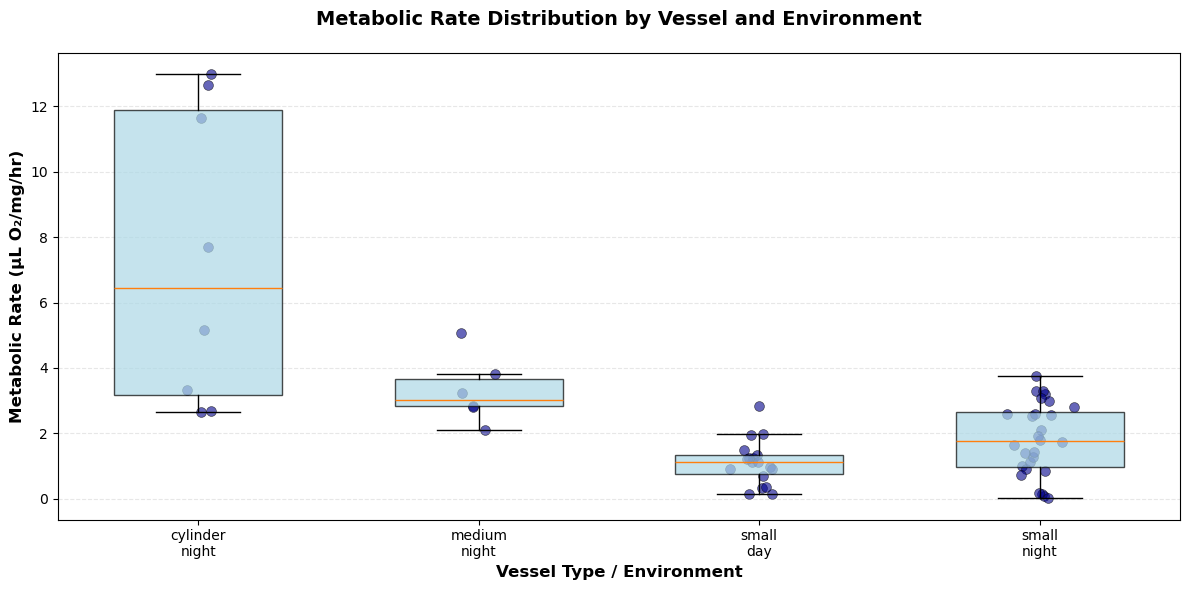

In [55]:
import matplotlib.pyplot as plt
import numpy as np


if 'agg_df' in locals() and not agg_df.empty:
    # Remove rows with negative consumption
    agg_df = agg_df[agg_df['uL_mg_hr'] >= 0].copy()
    # Group by vessel and environment if those columns exist
    group_cols = [col for col in ['vessel', 'environment'] if col in agg_df.columns]

    
    if group_cols:
        stats = agg_df.groupby(group_cols)['uL_mg_hr'].agg(['count', 'mean', 'std', 'min', 'max'])
        print("\nSummary statistics by group:")
        display(stats)
        
        # Create box and whisker plot with individual data points
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Create a combined grouping column for x-axis
        agg_df['group'] = agg_df['vessel'] + '\n' + agg_df['environment']
        
        # Get unique groups and sort them
        groups = agg_df['group'].unique()
        groups = sorted(groups)
        
        # Prepare data for box plot
        data_by_group = [agg_df[agg_df['group'] == g]['uL_mg_hr'].values for g in groups]
        
        # Create box plot
        bp = ax.boxplot(data_by_group, labels=groups, patch_artist=True,
                        widths=0.6, showfliers=False)
        
        # Style the boxes
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        
        # Overlay individual data points with jitter
        for i, group in enumerate(groups):
            y_data = agg_df[agg_df['group'] == group]['uL_mg_hr'].values
            # Add jitter to x positions
            x_data = np.random.normal(i + 1, 0.04, size=len(y_data))
            ax.scatter(x_data, y_data, alpha=0.6, s=50, c='darkblue', edgecolors='black', linewidth=0.5)
        
        # Labels and formatting
        ax.set_ylabel('Metabolic Rate (µL O₂/mg/hr)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Vessel Type / Environment', fontsize=12, fontweight='bold')
        ax.set_title('Metabolic Rate Distribution by Vessel and Environment', fontsize=14, fontweight='bold', pad=20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Rotate x-axis labels if needed
        plt.xticks(rotation=0, ha='center')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("\nOverall statistics:")
        print(agg_df['uL_mg_hr'].describe())
else:
    print("No data available for statistics.")

## Statistical Comparison: Day vs Night

Perform statistical tests to determine if metabolic rates differ significantly between day and night conditions.

In [56]:
from scipy import stats

if 'agg_df' in locals() and not agg_df.empty:
    # Remove rows with negative consumption
    filtered_df = agg_df[agg_df['uL_mg_hr'] >= 0].copy()
    # Test for each vessel type separately
    vessel_types = filtered_df['vessel'].unique()
    
    print("Statistical Tests: Day vs Night Metabolic Rates")
    print("=" * 70)
    
    for vessel in vessel_types:
        vessel_data = filtered_df[filtered_df['vessel'] == vessel]
        day_data = vessel_data[vessel_data['environment'] == 'day']['uL_mg_hr'].values
        night_data = vessel_data[vessel_data['environment'] == 'night']['uL_mg_hr'].values
        
        if len(day_data) > 0 and len(night_data) > 0:
            # Perform t-test (assumes normality)
            t_stat, p_value_t = stats.ttest_ind(night_data, day_data)
            
            # Perform Mann-Whitney U test (non-parametric alternative)
            u_stat, p_value_u = stats.mannwhitneyu(night_data, day_data, alternative='two-sided')
            
            print(f"\n{vessel.upper()} VESSELS:")
            print(f"  Night: n={len(night_data)}, mean={night_data.mean():.2f}, std={night_data.std():.2f}")
            print(f"  Day:   n={len(day_data)}, mean={day_data.mean():.2f}, std={day_data.std():.2f}")
            print(f"  Difference: {night_data.mean() - day_data.mean():.2f} µL O₂/mg/hr")
            print(f"  % Change: {((day_data.mean() - night_data.mean()) / night_data.mean() * 100):.1f}%")
            print(f"\n  Independent t-test:")
            print(f"    t-statistic = {t_stat:.3f}, p-value = {p_value_t:.4f}")
            print(f"    {'SIGNIFICANT' if p_value_t < 0.05 else 'NOT significant'} at α=0.05")
            print(f"\n  Mann-Whitney U test (non-parametric):")
            print(f"    U-statistic = {u_stat:.1f}, p-value = {p_value_u:.4f}")
            print(f"    {'SIGNIFICANT' if p_value_u < 0.05 else 'NOT significant'} at α=0.05")
        else:
            print(f"\n{vessel.upper()} VESSELS:")
            print(f"  Insufficient data for comparison (day={len(day_data)}, night={len(night_data)})")
    
    print("\n" + "=" * 70)
else:
    print("No data available for statistical analysis.")

Statistical Tests: Day vs Night Metabolic Rates

SMALL VESSELS:
  Night: n=28, mean=1.83, std=1.08
  Day:   n=18, mean=1.12, std=0.67
  Difference: 0.71 µL O₂/mg/hr
  % Change: -38.8%

  Independent t-test:
    t-statistic = 2.435, p-value = 0.0190
    SIGNIFICANT at α=0.05

  Mann-Whitney U test (non-parametric):
    U-statistic = 346.0, p-value = 0.0353
    SIGNIFICANT at α=0.05

CYLINDER VESSELS:
  Insufficient data for comparison (day=0, night=8)

MEDIUM VESSELS:
  Insufficient data for comparison (day=0, night=6)



In [27]:
# --- Merge agg_df with signal_rate_summary.csv to create merged_df ---
import pandas as pd

# Load the signal rate summary
signal_rate_path = OUT_DIR / 'signal_rate_summary.csv'
signal_df = pd.read_csv(signal_rate_path)

# Ensure columns are named consistently for merging
# (trial, brick, channel must exist in both dataframes)

# Merge only for rows where vessel == 'cylinder'
cylinder_mask = agg_df['vessel'] == 'cylinder'
agg_df_cyl = agg_df[cylinder_mask].copy()
agg_df_non_cyl = agg_df[~cylinder_mask].copy()

# Merge signal_rate into cylinder rows by trial, brick, channel
merged_cyl = pd.merge(
    agg_df_cyl,
    signal_df[['trial', 'brick', 'channel', 'signal_rate']],
    on=['trial', 'brick', 'channel'],
    how='left'
)

# For non-cylinder rows, set signal_rate to 0
agg_df_non_cyl['signal_rate'] = 0

# Concatenate back together
merged_df = pd.concat([merged_cyl, agg_df_non_cyl], ignore_index=True)

# Optional: sort for readability
merged_df = merged_df.sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)

display(merged_df.head())


,trial,brick,file,channel,uL_mg_hr,temp_C,vessel,date,environment,notes,signal_rate
0,trial1,box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,2.554332,27.948,small,10Nov2025,night,NaN,0.000000
1,trial1,box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch3,3.209139,27.948,small,10Nov2025,night,NaN,0.000000
2,trial1,box2,/Users/oakley/Documents/GitHub/signal_respirom...,Ch4,3.297355,27.948,small,10Nov2025,night,NaN,0.000000
3,trial1,box3,/Users/oakley/Documents/GitHub/signal_respirom...,Ch2,12.986348,28.233,cylinder,10Nov2025,night,NaN,9.745342
4,trial1,box3,/Users/oakley/Documents/GitHub/signal_respirom...,Ch3,12.664716,28.233,cylinder,10Nov2025,night,NaN,0.981366


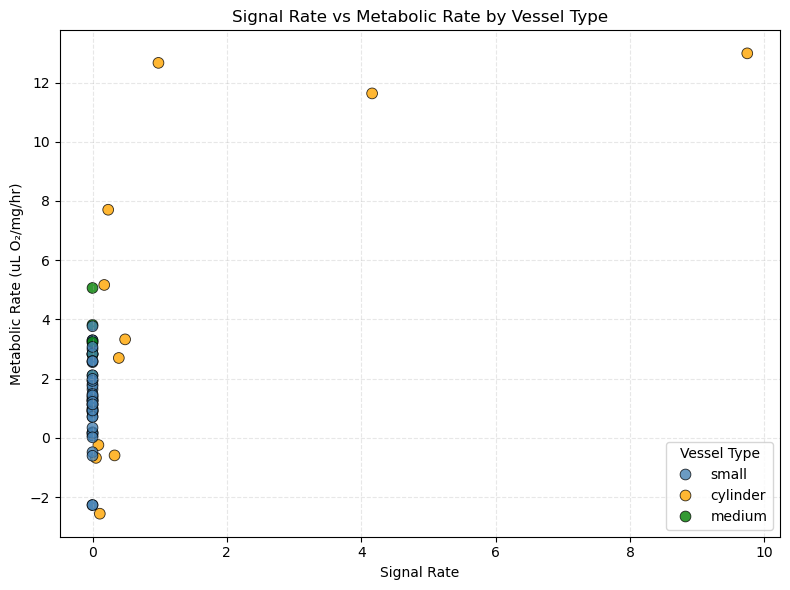

In [57]:
# Plot signal_rate vs uL_mg_hr, color by vessel type
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Only plot rows where signal_rate is not null (should be all, but just in case)
plot_df = merged_df.copy()

sns.scatterplot(
    data=plot_df,
    x='signal_rate',
    y='uL_mg_hr',
    hue='vessel',
    palette={'cylinder': 'orange', 'medium': 'green', 'small': 'steelblue'},
    s=60,
    edgecolor='black',
    alpha=0.8
)

plt.xlabel('Signal Rate')
plt.ylabel('Metabolic Rate (uL O₂/mg/hr)')
plt.title('Signal Rate vs Metabolic Rate by Vessel Type')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Vessel Type')
plt.tight_layout()
plt.show()
